# ragcli: Oracle Database 26ai RAG System Demo

This notebook demonstrates the capabilities of **ragcli**, a production-ready RAG (Retrieval-Augmented Generation) system that combines:

- **Oracle Database 26ai**: Vector search with HNSW/IVF indexing
- **Ollama**: Local LLM inference
- **langchain-oracledb**: Native Oracle AI integration

## Special Focus: langchain-oracledb Features

This demo highlights the Oracle-native AI capabilities:
- `OracleDocLoader` - Database-integrated document loading
- `OracleTextSplitter` - Server-side text chunking with normalization
- `OracleEmbeddings` - In-database embedding generation (ONNX models)
- `OracleSummary` - Database-powered text summarization

## Table of Contents

1. [Setup and Configuration](#1-setup-and-configuration)
2. [Database Connection](#2-database-connection)
3. [langchain-oracledb Features](#3-langchain-oracledb-features)
   - 3.1 OracleDocLoader
   - 3.2 OracleTextSplitter
   - 3.3 OracleEmbeddings
   - 3.4 OracleSummary
4. [Document Upload Pipeline](#4-document-upload-pipeline)
5. [RAG Query Workflow](#5-rag-query-workflow)
6. [Vector Similarity Search](#6-vector-similarity-search)
7. [Performance Metrics](#7-performance-metrics)
8. [Comparing Ollama vs Oracle Embeddings](#8-comparing-ollama-vs-oracle-embeddings)

---
## 1. Setup and Configuration

In [1]:
# Core imports
import sys
import os
from pathlib import Path
import json
import time

# Ensure ragcli is importable
sys.path.insert(0, str(Path('.').absolute()))

# ragcli imports
from ragcli.config.config_manager import load_config
from ragcli.database.oracle_client import OracleClient
from ragcli.core.rag_engine import upload_document, ask_query
from ragcli.core.document_processor import preprocess_document, chunk_text
from ragcli.core.embedding import generate_embedding, batch_generate_embeddings
from ragcli.core.similarity_search import search_chunks

# Visualization
import matplotlib.pyplot as plt
import numpy as np

# Pretty display
from IPython.display import display, Markdown, HTML
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports successful")

✅ Imports successful


In [2]:
# Load configuration
config = load_config()

print("📋 Configuration Overview")
print("="*50)
print(f"Oracle DSN: {config['oracle']['dsn']}")
print(f"Ollama Endpoint: {config['ollama']['endpoint']}")
print(f"Embedding Model: {config['ollama']['embedding_model']}")
print(f"Chat Model: {config['ollama']['chat_model']}")
print(f"Chunk Size: {config['documents']['chunk_size']} tokens")
print(f"Chunk Overlap: {config['documents']['chunk_overlap_percentage']}%")
print(f"Vector Dimension: {config['vector_index']['dimension']}")
print(f"Use Oracle Embeddings: {config['vector_index'].get('use_oracle_embeddings', False)}")

📋 Configuration Overview
Oracle DSN: (description= (retry_count=20)(retry_delay=3)(address=(protocol=tcps)(port=1521)(host=adb.us-phoenix-1.oraclecloud.com))(connect_data=(service_name=g2f4dc3e5463897_mern_tpurgent.adb.oraclecloud.com))(security=(ssl_server_dn_match=yes)))
Ollama Endpoint: http://localhost:11434
Embedding Model: nomic-embed-text
Chat Model: gemma3:270m
Chunk Size: 1000 tokens
Chunk Overlap: 10%
Vector Dimension: 768
Use Oracle Embeddings: False


---
## 2. Database Connection

In [3]:
# Test Oracle Database connection
client = OracleClient(config)

try:
    conn = client.get_connection()
    cursor = conn.cursor()
    
    # Get database version
    cursor.execute("SELECT BANNER FROM V$VERSION WHERE ROWNUM = 1")
    version = cursor.fetchone()[0]
    print(f"✅ Connected to Oracle Database")
    print(f"   Version: {version}")
    
    # Check for vector capabilities
    cursor.execute("""
        SELECT COUNT(*) FROM ALL_TABLES 
        WHERE TABLE_NAME = 'DOCUMENTS'
    """)
    has_tables = cursor.fetchone()[0] > 0
    print(f"   RAG Tables Initialized: {'Yes' if has_tables else 'No (run: python ragcli.py db init)'}")
    
    cursor.close()
except Exception as e:
    print(f"❌ Connection failed: {e}")
finally:
    if 'conn' in dir():
        conn.close()

✅ Connected to Oracle Database
   Version: Oracle AI Database 26ai Enterprise Edition Release 23.26.0.1.0 - for Oracle Cloud and Engineered Systems
   RAG Tables Initialized: Yes


In [4]:
# Get current database statistics
def get_db_stats():
    """Retrieve database statistics for documents and chunks."""
    client = OracleClient(config)
    conn = client.get_connection()
    cursor = conn.cursor()
    
    stats = {}
    
    try:
        # Document count
        cursor.execute("SELECT COUNT(*) FROM DOCUMENTS")
        stats['document_count'] = cursor.fetchone()[0]
        
        # Chunk count
        cursor.execute("SELECT COUNT(*) FROM CHUNKS")
        stats['chunk_count'] = cursor.fetchone()[0]
        
        # Total tokens
        cursor.execute("SELECT COALESCE(SUM(TOTAL_TOKENS), 0) FROM DOCUMENTS")
        stats['total_tokens'] = cursor.fetchone()[0]
        
        # Query count
        cursor.execute("SELECT COUNT(*) FROM QUERIES")
        stats['query_count'] = cursor.fetchone()[0]
        
    except Exception as e:
        print(f"Warning: Could not fetch stats: {e}")
    finally:
        cursor.close()
        conn.close()
        client.close()
    
    return stats

stats = get_db_stats()
print("📊 Current Database Statistics")
print("="*50)
print(f"Documents: {stats.get('document_count', 0)}")
print(f"Chunks: {stats.get('chunk_count', 0)}")
print(f"Total Tokens: {stats.get('total_tokens', 0):,}")
print(f"Queries Logged: {stats.get('query_count', 0)}")

📊 Current Database Statistics
Documents: 10
Chunks: 22
Total Tokens: 15,856
Queries Logged: 11


---
## 3. langchain-oracledb Features

This section demonstrates the Oracle AI Vector Search integration via `langchain-oracledb`.

**Key Components:**
- `OracleDocLoader`: Load documents using Oracle's document loaders
- `OracleTextSplitter`: Database-side chunking with normalization
- `OracleEmbeddings`: In-database embedding generation using ONNX models
- `OracleSummary`: Generate summaries using Oracle AI utilities

In [5]:
# Check langchain-oracledb availability
try:
    from langchain_oracledb.document_loaders.oracleai import OracleDocLoader, OracleTextSplitter
    from langchain_oracledb.utilities.oracleai import OracleSummary
    from langchain_oracledb.embeddings.oracleai import OracleEmbeddings
    from langchain_oracledb.document_loaders import OracleAutonomousDatabaseLoader
    HAS_ORACLE_LANGCHAIN = True
    print("✅ langchain-oracledb is installed and available")
    print("")
    print("Available components:")
    print("  • OracleDocLoader - Document loading")
    print("  • OracleTextSplitter - Text chunking")
    print("  • OracleEmbeddings - Vector embeddings")
    print("  • OracleSummary - Text summarization")
    print("  • OracleAutonomousDatabaseLoader - ADB integration")
except ImportError as e:
    HAS_ORACLE_LANGCHAIN = False
    print(f"❌ langchain-oracledb not installed: {e}")
    print("   Install with: pip install langchain-oracledb")

✅ langchain-oracledb is installed and available

Available components:
  • OracleDocLoader - Document loading
  • OracleTextSplitter - Text chunking
  • OracleEmbeddings - Vector embeddings
  • OracleSummary - Text summarization
  • OracleAutonomousDatabaseLoader - ADB integration


In [6]:
# Initialize Oracle Integration Manager
from ragcli.core.oracle_integration import OracleIntegrationManager

if HAS_ORACLE_LANGCHAIN:
    client = OracleClient(config)
    conn = client.get_connection()
    manager = OracleIntegrationManager(conn)
    print("✅ OracleIntegrationManager initialized")
else:
    print("⚠️ Skipping - langchain-oracledb not available")

✅ OracleIntegrationManager initialized


### 3.1 OracleDocLoader

The `OracleDocLoader` loads documents using Oracle's native document processing capabilities. It can load from:
- Local files
- Oracle Database tables
- Various document formats

In [7]:
# Create a sample document for testing
sample_dir = Path("demo_data")
sample_dir.mkdir(exist_ok=True)

sample_content = """
Oracle Database 26ai: Next-Generation AI Capabilities

Oracle Database 26ai represents a significant advancement in database technology,
integrating native AI and machine learning capabilities directly within the database engine.

Key Features:
1. AI Vector Search - Native vector similarity search with HNSW and IVF indexing
2. In-Database ML - Run machine learning models without data movement
3. ONNX Model Support - Deploy pre-trained models directly in the database
4. Natural Language Processing - Text analysis and embedding generation

The langchain-oracledb library provides seamless integration between LangChain
and Oracle Database, enabling developers to build sophisticated RAG applications
with enterprise-grade reliability and performance.

Use Cases:
- Document retrieval systems
- Semantic search applications
- AI-powered chatbots
- Knowledge management systems
"""

sample_file = sample_dir / "oracle_26ai_overview.txt"
sample_file.write_text(sample_content)
print(f"✅ Created sample document: {sample_file}")
print(f"   Size: {len(sample_content)} characters")

✅ Created sample document: demo_data/oracle_26ai_overview.txt
   Size: 881 characters


In [8]:
# Test OracleDocLoader
if HAS_ORACLE_LANGCHAIN:
    print("📄 Testing OracleDocLoader")
    print("="*50)
    
    try:
        # Load document using Oracle loader
        docs = manager.load_document(str(sample_file.absolute()))
        
        if docs and len(docs) > 0:
            print(f"✅ Successfully loaded {len(docs)} document(s)")
            print(f"")
            print(f"Document Content Preview:")
            print("-"*40)
            preview = docs[0].page_content[:300] + "..." if len(docs[0].page_content) > 300 else docs[0].page_content
            print(preview)
        else:
            print("⚠️ No documents loaded")
            
    except Exception as e:
        print(f"⚠️ OracleDocLoader test: {e}")
        print("   Note: Some Oracle AI features require specific database configuration")
else:
    print("⚠️ Skipping - langchain-oracledb not available")

📄 Testing OracleDocLoader
✅ Successfully loaded 1 document(s)

Document Content Preview:
----------------------------------------
 Oracle Database 26ai: Next-Generation AI Capabilities  Oracle Database 26ai represents a significant advancement in database technology, integrating native AI and machine learning capabilities directly within the database engine.  Key Features: 1. AI Vector Search - Native vector similarity search ...


### 3.2 OracleTextSplitter

The `OracleTextSplitter` performs server-side text chunking with multiple strategies:
- **By characters**: Split at character boundaries (max 500)
- **By words**: Split at word boundaries (max 100)
- **By sentences**: Intelligent sentence-based splitting (max 20)

It also supports text normalization for consistent preprocessing.

In [9]:
# Test OracleTextSplitter
if HAS_ORACLE_LANGCHAIN:
    print("✂️ Testing OracleTextSplitter")
    print("="*50)
    
    test_text = """Artificial intelligence (AI) is intelligence demonstrated by machines. 
    Machine learning is a subset of AI that enables systems to learn from data. 
    Deep learning uses neural networks with multiple layers. 
    Natural language processing (NLP) enables computers to understand human language."""
    
    print(f"Input text: {len(test_text)} characters")
    print("")
    
    # Test sentence-based splitting
    print("1️⃣ Sentence-based splitting:")
    try:
        params_sentence = {"by": "words", "split": "sentence", "max": 100, "normalize": "all"}
        chunks_sentence = manager.split_text(text=test_text, params=params_sentence)
        print(f"   Result: {len(chunks_sentence)} chunks")
        for i, chunk in enumerate(chunks_sentence[:3]):
            print(f"   Chunk {i+1}: {chunk[:60]}..." if len(chunk) > 60 else f"   Chunk {i+1}: {chunk}")
    except Exception as e:
        print(f"   Error: {e}")
    
    print("")
    
    # Test character-based splitting
    print("2️⃣ Character-based splitting:")
    try:
        params_chars = {"by": "characters", "split": "none", "max": 100, "normalize": "all"}
        chunks_chars = manager.split_text(text=test_text, params=params_chars)
        print(f"   Result: {len(chunks_chars)} chunks")
        for i, chunk in enumerate(chunks_chars[:3]):
            print(f"   Chunk {i+1} ({len(chunk)} chars): {chunk[:50]}...")
    except Exception as e:
        print(f"   Error: {e}")
else:
    print("⚠️ Skipping - langchain-oracledb not available")

✂️ Testing OracleTextSplitter
Input text: 300 characters

1️⃣ Sentence-based splitting:
   Result: 1 chunks
   Chunk 1: Artificial intelligence (AI) is intelligence demonstrated by...

2️⃣ Character-based splitting:
   Result: 3 chunks
   Chunk 1 (99 chars): Artificial intelligence (AI) is intelligence demon...
   Chunk 2 (100 chars): of AI that enables systems to learn from data.
Dee...
   Chunk 3 (85 chars): rs.
Natural language processing (NLP) enables comp...


### 3.3 OracleEmbeddings

The `OracleEmbeddings` class generates vector embeddings through multiple providers:

| Provider | Description |
|----------|-------------|
| `database` | Local ONNX models loaded in Oracle Database (e.g., ALL_MINILM_L12_V2) |
| `ocigenai` | OCI GenAI with Cohere models |
| `huggingface` | HuggingFace sentence-transformers |

**Advantage**: In-database embeddings eliminate external API calls and data movement.

In [10]:
# Test OracleEmbeddings
if HAS_ORACLE_LANGCHAIN:
    print("🔢 Testing OracleEmbeddings")
    print("="*50)
    
    test_texts = [
        "Oracle Database provides enterprise-grade AI capabilities.",
        "Vector search enables semantic similarity matching.",
        "Machine learning models can run inside the database."
    ]
    
    try:
        # Use database provider with ALL_MINILM_L12_V2 model
        params = {"provider": "database", "model": "ALL_MINILM_L12_V2"}
        
        start_time = time.time()
        embeddings = manager.generate_embeddings(test_texts, params=params)
        elapsed = time.time() - start_time
        
        if embeddings and len(embeddings) > 0:
            print(f"✅ Generated {len(embeddings)} embeddings")
            print(f"   Dimension: {len(embeddings[0])}")
            print(f"   Time: {elapsed*1000:.2f} ms")
            print(f"   Provider: database (ONNX)")
            print(f"   Model: ALL_MINILM_L12_V2")
            print("")
            print("   Sample embedding (first 10 values):")
            print(f"   {embeddings[0][:10]}")
        else:
            print("⚠️ No embeddings returned")
            
    except Exception as e:
        print(f"⚠️ OracleEmbeddings test: {e}")
        print("   Note: Ensure the ONNX model is loaded in Oracle Database")
        print("   Check with: SELECT MODEL_NAME FROM USER_MINING_MODELS")
else:
    print("⚠️ Skipping - langchain-oracledb not available")

🔢 Testing OracleEmbeddings
✅ Generated 3 embeddings
   Dimension: 384
   Time: 1009.69 ms
   Provider: database (ONNX)
   Model: ALL_MINILM_L12_V2

   Sample embedding (first 10 values):
   [0.0019562128, -0.0239340458, -0.0302166697, -0.0731686875, -0.0598886609, -0.0229796544, -0.0847786814, 0.0135877319, 0.044513274, -0.0247141309]


📐 Embedding Similarity Analysis
Pairwise Cosine Similarities:
   Text 1 <-> Text 2: 0.1999
   Text 1 <-> Text 3: 0.6214
   Text 2 <-> Text 3: 0.1613


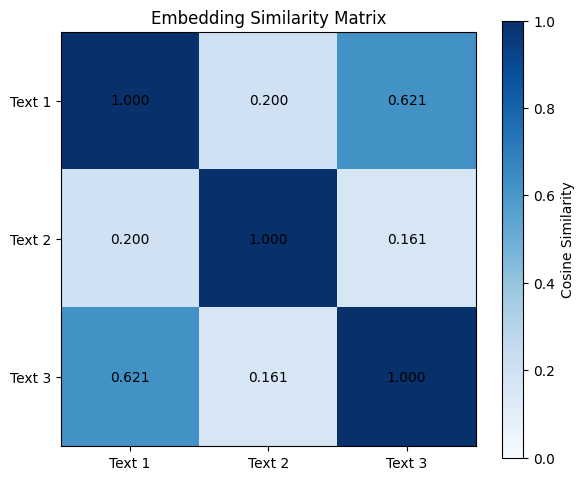

In [11]:
# Calculate similarity between embeddings
def cosine_similarity(v1, v2):
    """Calculate cosine similarity between two vectors."""
    v1, v2 = np.array(v1), np.array(v2)
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

if HAS_ORACLE_LANGCHAIN and 'embeddings' in dir() and embeddings:
    print("📐 Embedding Similarity Analysis")
    print("="*50)
    
    # Calculate pairwise similarities
    labels = ["Text 1", "Text 2", "Text 3"]
    
    print("Pairwise Cosine Similarities:")
    for i in range(len(embeddings)):
        for j in range(i+1, len(embeddings)):
            sim = cosine_similarity(embeddings[i], embeddings[j])
            print(f"   {labels[i]} <-> {labels[j]}: {sim:.4f}")
    
    # Visualize as heatmap
    n = len(embeddings)
    sim_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            sim_matrix[i][j] = cosine_similarity(embeddings[i], embeddings[j])
    
    plt.figure(figsize=(6, 5))
    plt.imshow(sim_matrix, cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(label='Cosine Similarity')
    plt.xticks(range(n), labels)
    plt.yticks(range(n), labels)
    plt.title('Embedding Similarity Matrix')
    for i in range(n):
        for j in range(n):
            plt.text(j, i, f'{sim_matrix[i][j]:.3f}', ha='center', va='center')
    plt.tight_layout()
    plt.show()

### 3.4 OracleSummary

The `OracleSummary` utility generates text summaries using:
- Oracle Database native summarization
- OCI GenAI with Cohere Command
- HuggingFace BART models

In [12]:
# Test OracleSummary
if HAS_ORACLE_LANGCHAIN:
    print("📝 Testing OracleSummary")
    print("="*50)
    
    text_to_summarize = """
    Artificial intelligence (AI) is intelligence demonstrated by machines, 
    as opposed to the natural intelligence displayed by humans or animals. 
    Leading AI textbooks define the field as the study of "intelligent agents": 
    any system that perceives its environment and takes actions that maximize 
    its chance of achieving its goals. Some popular accounts use the term 
    "artificial intelligence" to describe machines that mimic cognitive functions 
    that humans associate with the human mind, such as learning and problem-solving.
    
    Machine learning (ML) is the study of computer algorithms that can improve 
    automatically through experience and by the use of data. It is seen as a 
    part of artificial intelligence. Machine learning algorithms build a model 
    based on sample data, known as training data, in order to make predictions 
    or decisions without being explicitly programmed to do so.
    """
    
    print(f"Input: {len(text_to_summarize)} characters")
    print("")
    
    try:
        start_time = time.time()
        summary = manager.generate_summary(text_to_summarize, provider="database")
        elapsed = time.time() - start_time
        
        if summary:
            print(f"✅ Summary generated in {elapsed*1000:.2f} ms")
            print(f"   Output: {len(summary)} characters")
            print("")
            print("Summary:")
            print("-"*40)
            print(summary)
        else:
            print("⚠️ Empty summary returned")
            
    except Exception as e:
        print(f"⚠️ OracleSummary test: {e}")
        print("   Note: Summary feature may require specific Oracle AI configuration")
else:
    print("⚠️ Skipping - langchain-oracledb not available")

📝 Testing OracleSummary
Input: 942 characters

✅ Summary generated in 238.42 ms
   Output: 1 characters

Summary:
----------------------------------------
['Leading AI textbooks define the field as the study of "intelligent agents":      any system that perceives its environment and takes actions that maximize      its chance of achieving its goals.\n\n']


In [13]:
# Clean up Oracle connection from Section 3
if 'conn' in dir() and conn:
    conn.close()
if 'client' in dir() and client:
    client.close()
print("✅ Oracle connection closed")

✅ Oracle connection closed


---
## 4. Document Upload Pipeline

The ragcli document pipeline:
1. **Preprocess** - Extract text from PDF/MD/TXT
2. **Chunk** - Split into token-based chunks with overlap
3. **Embed** - Generate vector embeddings (Ollama or Oracle)
4. **Store** - Insert into Oracle vector store with HNSW index

In [14]:
# Create a more substantial demo document
demo_content = """
# Understanding RAG (Retrieval-Augmented Generation)

## Introduction

Retrieval-Augmented Generation (RAG) is a technique that combines the power of 
large language models (LLMs) with external knowledge retrieval. Unlike traditional 
LLMs that rely solely on their training data, RAG systems can access and incorporate 
up-to-date information from external sources.

## How RAG Works

The RAG pipeline consists of several key steps:

1. **Document Ingestion**: Documents are loaded and preprocessed to extract text content.
   This includes handling various formats like PDF, Markdown, and plain text.

2. **Chunking**: Large documents are split into smaller, manageable chunks. This is 
   crucial because embedding models and LLMs have context length limitations. Typical 
   chunk sizes range from 500 to 2000 tokens with 10-20% overlap to maintain context.

3. **Embedding Generation**: Each chunk is converted into a dense vector representation 
   using an embedding model. These vectors capture the semantic meaning of the text.

4. **Vector Storage**: Embeddings are stored in a vector database with efficient 
   similarity search capabilities. Common indexing methods include HNSW (Hierarchical 
   Navigable Small World) and IVF (Inverted File Index).

5. **Query Processing**: When a user asks a question, it's also converted to an 
   embedding vector using the same model.

6. **Similarity Search**: The query embedding is compared against stored chunk 
   embeddings to find the most relevant passages.

7. **Context Assembly**: Retrieved chunks are assembled into a context that's 
   passed to the LLM along with the original query.

8. **Response Generation**: The LLM generates a response informed by both its 
   training and the retrieved context.

## Benefits of RAG

- **Accuracy**: Responses are grounded in actual documents rather than potentially 
  outdated training data.
- **Transparency**: Sources can be cited and verified.
- **Efficiency**: No need to fine-tune models for specific domains.
- **Freshness**: Knowledge base can be updated without retraining.

## Oracle Database 26ai for RAG

Oracle Database 26ai provides enterprise-grade infrastructure for RAG applications:

- Native vector similarity search with HNSW indexing
- In-database embedding generation using ONNX models
- Seamless integration with langchain-oracledb
- ACID compliance for mission-critical applications
- Advanced security and access control
"""

demo_file = sample_dir / "rag_overview.md"
demo_file.write_text(demo_content)
print(f"✅ Created demo document: {demo_file}")
print(f"   Size: {len(demo_content)} characters")

✅ Created demo document: demo_data/rag_overview.md
   Size: 2455 characters


In [15]:
# Demonstrate document preprocessing
print("📄 Document Preprocessing")
print("="*50)

text, ocr_used = preprocess_document(str(demo_file), config)

print(f"File: {demo_file.name}")
print(f"Extracted text: {len(text)} characters")
print(f"OCR processed: {ocr_used}")
print("")
print("Preview (first 500 chars):")
print("-"*40)
print(text[:500])

📄 Document Preprocessing
File: rag_overview.md
Extracted text: 2455 characters
OCR processed: False

Preview (first 500 chars):
----------------------------------------

# Understanding RAG (Retrieval-Augmented Generation)

## Introduction

Retrieval-Augmented Generation (RAG) is a technique that combines the power of 
large language models (LLMs) with external knowledge retrieval. Unlike traditional 
LLMs that rely solely on their training data, RAG systems can access and incorporate 
up-to-date information from external sources.

## How RAG Works

The RAG pipeline consists of several key steps:

1. **Document Ingestion**: Documents are loaded and preprocessed


In [16]:
# Demonstrate text chunking
print("✂️ Text Chunking")
print("="*50)

chunks = chunk_text(text, config)

print(f"Chunk size: {config['documents']['chunk_size']} tokens")
print(f"Overlap: {config['documents']['chunk_overlap_percentage']}%")
print(f"Total chunks: {len(chunks)}")
print("")

# Display chunk statistics
total_tokens = sum(c['token_count'] for c in chunks)
avg_tokens = total_tokens / len(chunks) if chunks else 0

print(f"Total tokens: {total_tokens}")
print(f"Average tokens per chunk: {avg_tokens:.1f}")
print("")

print("Chunk Details:")
print("-"*40)
for i, chunk in enumerate(chunks[:5]):  # Show first 5
    preview = chunk['text'][:80].replace('\n', ' ')
    print(f"Chunk {i+1}: {chunk['token_count']} tokens - \"{preview}...\"")
if len(chunks) > 5:
    print(f"... and {len(chunks)-5} more chunks")

✂️ Text Chunking
Chunk size: 1000 tokens
Overlap: 10%
Total chunks: 1

Total tokens: 512
Average tokens per chunk: 512.0

Chunk Details:
----------------------------------------
Chunk 1: 512 tokens - " # Understanding RAG (Retrieval-Augmented Generation)  ## Introduction  Retrieva..."


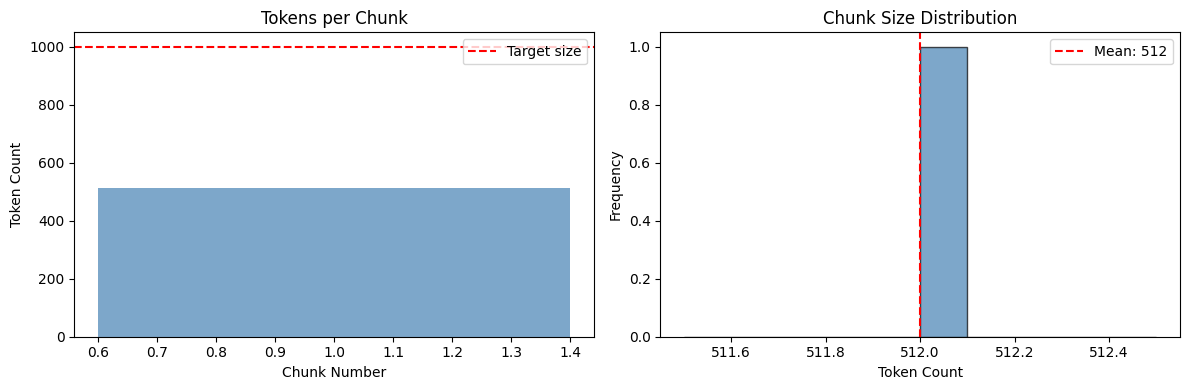

In [17]:
# Visualize chunk distribution
if chunks:
    token_counts = [c['token_count'] for c in chunks]
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Bar chart of chunk sizes
    axes[0].bar(range(1, len(chunks)+1), token_counts, color='steelblue', alpha=0.7)
    axes[0].axhline(y=config['documents']['chunk_size'], color='red', linestyle='--', label='Target size')
    axes[0].set_xlabel('Chunk Number')
    axes[0].set_ylabel('Token Count')
    axes[0].set_title('Tokens per Chunk')
    axes[0].legend()
    
    # Distribution histogram
    axes[1].hist(token_counts, bins=10, color='steelblue', alpha=0.7, edgecolor='black')
    axes[1].axvline(x=np.mean(token_counts), color='red', linestyle='--', label=f'Mean: {np.mean(token_counts):.0f}')
    axes[1].set_xlabel('Token Count')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Chunk Size Distribution')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

In [18]:
# Full document upload (includes embedding and storage)
print("📤 Full Document Upload Pipeline")
print("="*50)

try:
    result = upload_document(str(demo_file), config)
    
    print(f"✅ Document uploaded successfully!")
    print("")
    print("Upload Results:")
    print("-"*40)
    print(f"Document ID: {result['document_id']}")
    print(f"Filename: {result['filename']}")
    print(f"Format: {result['file_format']}")
    print(f"File Size: {result['file_size_bytes'] / 1024:.2f} KB")
    print(f"Chunks Created: {result['chunk_count']}")
    print(f"Total Tokens: {result['total_tokens']}")
    print(f"Embedding Dimension: {result['embedding_dimension']}")
    print(f"Upload Time: {result['upload_time_ms']:.2f} ms")
    
    # Store for later use
    uploaded_doc_id = result['document_id']
    
except Exception as e:
    print(f"❌ Upload failed: {e}")
    uploaded_doc_id = None

📤 Full Document Upload Pipeline
✅ Document uploaded successfully!

Upload Results:
----------------------------------------
Document ID: 4b384d75-8cbb-4e74-95e1-201d5d72e1fd
Filename: rag_overview.md
Format: md
File Size: 2.40 KB
Chunks Created: 1
Total Tokens: 512
Embedding Dimension: 768
Upload Time: 1829.20 ms


---
## 5. RAG Query Workflow

Now let's query our uploaded document using the full RAG pipeline.

In [19]:
# RAG Query Example 1
print("🔍 RAG Query: What is RAG?")
print("="*50)

query = "What is RAG and how does it work?"

try:
    result = ask_query(
        query=query,
        top_k=3,
        min_similarity=0.5,
        config=config,
        include_embeddings=True
    )
    
    print(f"Query: {query}")
    print("")
    print("📊 Retrieved Chunks:")
    print("-"*40)
    for i, r in enumerate(result['results']):
        print(f"\n[{i+1}] Similarity: {r['similarity_score']:.4f}")
        preview = r['text'][:200].replace('\n', ' ')
        print(f"    {preview}...")
    
    print("")
    print("💬 Generated Response:")
    print("-"*40)
    print(result['response'])
    
    print("")
    print("⏱️ Performance Metrics:")
    print("-"*40)
    print(f"Search time: {result['metrics']['search_time_ms']:.2f} ms")
    print(f"Generation time: {result['metrics']['generation_time_ms']:.2f} ms")
    print(f"Total time: {result['metrics']['total_time_ms']:.2f} ms")
    
except Exception as e:
    print(f"❌ Query failed: {e}")

🔍 RAG Query: What is RAG?


[01/25/26 13:35:52] ERROR    Failed to generate response for model gemma3:270m                                     
                             ╭──────────────────────── Traceback (most recent call last) ─────────────────────────╮
                             │ /home/ubuntu/miniconda3/lib/python3.12/site-packages/urllib3/connectionpool.py:534 │
                             │ in _make_request                                                                   │
                             │                                                                                    │
                             │    531 │   │                                                                       │
                             │    532 │   │   # Receive the response from the server                              │
                             │    533 │   │   try:                                                                │
                             │ ❱  534 │   │   │   response = conn.getresponse()                                   │
                             │    535 │   │   except (BaseSSLError, OSError) as e:                                │
                             │    536 │   │   │   self._raise_timeout(err=e, url=url, timeout_value=read_timeout) │
                             │    537 │   │   │   raise                                                           │
                             │                                                                                    │
                             │ /home/ubuntu/miniconda3/lib/python3.12/site-packages/urllib3/connection.py:571 in  │
                             │ getresponse                                                                        │
                             │                                                                                    │
                             │    568 │   │   _shutdown = getattr(self.sock, "shutdown", None)                    │
                             │    569 │   │                                                                       │
                             │    570 │   │   # Get the response from http.client.HTTPConnection                  │
                             │ ❱  571 │   │   httplib_response = super().getresponse()                            │
                             │    572 │   │                                                                       │
                             │    573 │   │   try:                                                                │
                             │    574 │   │   │   assert_header_parsing(httplib_response.msg)                     │
                             │                                                                                    │
                             │ /home/ubuntu/miniconda3/lib/python3.12/http/client.py:1423 in getresponse          │
                             │                                                                                    │
                             │   1420 │   │                                                                       │
                             │   1421 │   │   try:                                                                │
                             │   1422 │   │   │   try:                                                            │
                             │ ❱ 1423 │   │   │   │   response.begin()                                            │
                             │   1424 │   │   │   except ConnectionError:                                         │
                             │   1425 │   │   │   │   self.close()                                                │
                             │   1426 │   │   │   │   raise                                                       │
                             │                                                                                    │
                             │ /home/ubuntu/miniconda3/l

2026-01-25 13:35:52,508 - ERROR - Failed to generate response for model gemma3:270m
Traceback (most recent call last):
  File "/home/ubuntu/miniconda3/lib/python3.12/site-packages/urllib3/connectionpool.py", line 534, in _make_request
    response = conn.getresponse()
               ^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/miniconda3/lib/python3.12/site-packages/urllib3/connection.py", line 571, in getresponse
    httplib_response = super().getresponse()
                       ^^^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/miniconda3/lib/python3.12/http/client.py", line 1423, in getresponse
    response.begin()
  File "/home/ubuntu/miniconda3/lib/python3.12/http/client.py", line 331, in begin
    version, status, reason = self._read_status()
                              ^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/miniconda3/lib/python3.12/http/client.py", line 292, in _read_status
    line = str(self.fp.readline(_MAXLINE + 1), "iso-8859-1")
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File

❌ Query failed: Response generation failed: HTTPConnectionPool(host='localhost', port=11434): Read timed out. (read timeout=30)


In [20]:
# RAG Query Example 2
print("🔍 RAG Query: Oracle Database capabilities")
print("="*50)

query = "What are the benefits of using Oracle Database for RAG applications?"

try:
    result = ask_query(
        query=query,
        top_k=3,
        config=config
    )
    
    print(f"Query: {query}")
    print("")
    print("💬 Response:")
    print("-"*40)
    print(result['response'])
    
    print("")
    print(f"Retrieved {len(result['results'])} relevant chunks")
    print(f"Total time: {result['metrics']['total_time_ms']:.2f} ms")
    
except Exception as e:
    print(f"❌ Query failed: {e}")

🔍 RAG Query: Oracle Database capabilities


[01/25/26 13:37:27] ERROR    Failed to generate response for model gemma3:270m                                     
                             ╭──────────────────────── Traceback (most recent call last) ─────────────────────────╮
                             │ /home/ubuntu/miniconda3/lib/python3.12/site-packages/urllib3/connectionpool.py:534 │
                             │ in _make_request                                                                   │
                             │                                                                                    │
                             │    531 │   │                                                                       │
                             │    532 │   │   # Receive the response from the server                              │
                             │    533 │   │   try:                                                                │
                             │ ❱  534 │   │   │   response = conn.getresponse()                                   │
                             │    535 │   │   except (BaseSSLError, OSError) as e:                                │
                             │    536 │   │   │   self._raise_timeout(err=e, url=url, timeout_value=read_timeout) │
                             │    537 │   │   │   raise                                                           │
                             │                                                                                    │
                             │ /home/ubuntu/miniconda3/lib/python3.12/site-packages/urllib3/connection.py:571 in  │
                             │ getresponse                                                                        │
                             │                                                                                    │
                             │    568 │   │   _shutdown = getattr(self.sock, "shutdown", None)                    │
                             │    569 │   │                                                                       │
                             │    570 │   │   # Get the response from http.client.HTTPConnection                  │
                             │ ❱  571 │   │   httplib_response = super().getresponse()                            │
                             │    572 │   │                                                                       │
                             │    573 │   │   try:                                                                │
                             │    574 │   │   │   assert_header_parsing(httplib_response.msg)                     │
                             │                                                                                    │
                             │ /home/ubuntu/miniconda3/lib/python3.12/http/client.py:1423 in getresponse          │
                             │                                                                                    │
                             │   1420 │   │                                                                       │
                             │   1421 │   │   try:                                                                │
                             │   1422 │   │   │   try:                                                            │
                             │ ❱ 1423 │   │   │   │   response.begin()                                            │
                             │   1424 │   │   │   except ConnectionError:                                         │
                             │   1425 │   │   │   │   self.close()                                                │
                             │   1426 │   │   │   │   raise                                                       │
                             │                                                                                    │
                             │ /home/ubuntu/miniconda3/l

2026-01-25 13:37:27,409 - ERROR - Failed to generate response for model gemma3:270m
Traceback (most recent call last):
  File "/home/ubuntu/miniconda3/lib/python3.12/site-packages/urllib3/connectionpool.py", line 534, in _make_request
    response = conn.getresponse()
               ^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/miniconda3/lib/python3.12/site-packages/urllib3/connection.py", line 571, in getresponse
    httplib_response = super().getresponse()
                       ^^^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/miniconda3/lib/python3.12/http/client.py", line 1423, in getresponse
    response.begin()
  File "/home/ubuntu/miniconda3/lib/python3.12/http/client.py", line 331, in begin
    version, status, reason = self._read_status()
                              ^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/miniconda3/lib/python3.12/http/client.py", line 292, in _read_status
    line = str(self.fp.readline(_MAXLINE + 1), "iso-8859-1")
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File

❌ Query failed: Response generation failed: HTTPConnectionPool(host='localhost', port=11434): Read timed out. (read timeout=30)


---
## 6. Vector Similarity Search

Deep dive into the similarity search mechanism.

In [21]:
# Direct similarity search
print("🔎 Vector Similarity Search")
print("="*50)

test_queries = [
    "How does embedding generation work?",
    "What indexing methods are available for vectors?",
    "Explain the benefits of RAG systems"
]

for query in test_queries:
    print(f"\nQuery: {query}")
    print("-"*40)
    
    try:
        result = search_chunks(
            query=query,
            top_k=2,
            min_similarity=0.3,
            config=config
        )
        
        for i, r in enumerate(result['results']):
            preview = r['text'][:100].replace('\n', ' ')
            print(f"  [{i+1}] Score: {r['similarity_score']:.4f} | {preview}...")
        
        print(f"  Time: {result['metrics']['total_time_ms']:.2f} ms")
        
    except Exception as e:
        print(f"  Error: {e}")

🔎 Vector Similarity Search

Query: How does embedding generation work?
----------------------------------------
  [1] Score: 0.5362 |  # Understanding RAG (Retrieval-Augmented Generation)  ## Introduction  Retrieval-Augmented Generati...
  [2] Score: 0.4970 | This is a small test document for ragcli. It contains some text to verify the upload and chunking pr...
  Time: 659.60 ms

Query: What indexing methods are available for vectors?
----------------------------------------
  [1] Score: 0.6335 |  # Understanding RAG (Retrieval-Augmented Generation)  ## Introduction  Retrieval-Augmented Generati...
  [2] Score: 0.5716 |  elit et adipiscing eiusmod tempor elit amet amet do ut dolor aliqua. amet Oracle AI sed do consecte...
  Time: 651.03 ms

Query: Explain the benefits of RAG systems
----------------------------------------
  [1] Score: 0.4650 |  # Understanding RAG (Retrieval-Augmented Generation)  ## Introduction  Retrieval-Augmented Generati...
  [2] Score: 0.4623 | ``` AGENT FACTORY

📊 Query Embedding Comparison


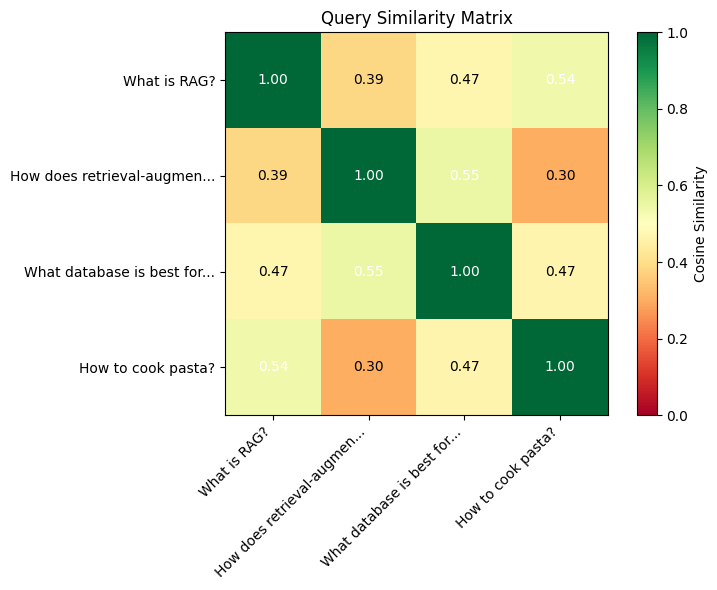


Observations:
- Similar queries (RAG related) have high similarity scores
- Unrelated query (cooking) has low similarity to others


In [22]:
# Compare query embeddings
print("📊 Query Embedding Comparison")
print("="*50)

queries = [
    "What is RAG?",
    "How does retrieval-augmented generation work?",
    "What database is best for machine learning?",
    "How to cook pasta?"
]

try:
    # Generate embeddings for comparison
    query_embeddings = []
    for q in queries:
        emb = generate_embedding(q, config['ollama']['embedding_model'], config)
        query_embeddings.append(emb)
    
    # Calculate similarity matrix
    n = len(queries)
    sim_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            sim_matrix[i][j] = cosine_similarity(query_embeddings[i], query_embeddings[j])
    
    # Visualize
    plt.figure(figsize=(8, 6))
    plt.imshow(sim_matrix, cmap='RdYlGn', vmin=0, vmax=1)
    plt.colorbar(label='Cosine Similarity')
    
    # Add labels
    short_labels = [q[:25] + "..." if len(q) > 25 else q for q in queries]
    plt.xticks(range(n), short_labels, rotation=45, ha='right')
    plt.yticks(range(n), short_labels)
    
    # Add values
    for i in range(n):
        for j in range(n):
            color = 'white' if sim_matrix[i][j] > 0.5 else 'black'
            plt.text(j, i, f'{sim_matrix[i][j]:.2f}', ha='center', va='center', color=color)
    
    plt.title('Query Similarity Matrix')
    plt.tight_layout()
    plt.show()
    
    print("\nObservations:")
    print("- Similar queries (RAG related) have high similarity scores")
    print("- Unrelated query (cooking) has low similarity to others")
    
except Exception as e:
    print(f"Error: {e}")

---
## 7. Performance Metrics

Analyze the performance characteristics of the RAG system.

⏱️ Embedding Generation Benchmark
Text 1: 11 chars, 2 words -> 22.01 ms
Text 2: 88 chars, 16 words -> 26.32 ms
Text 3: 307 chars, 43 words -> 32.41 ms


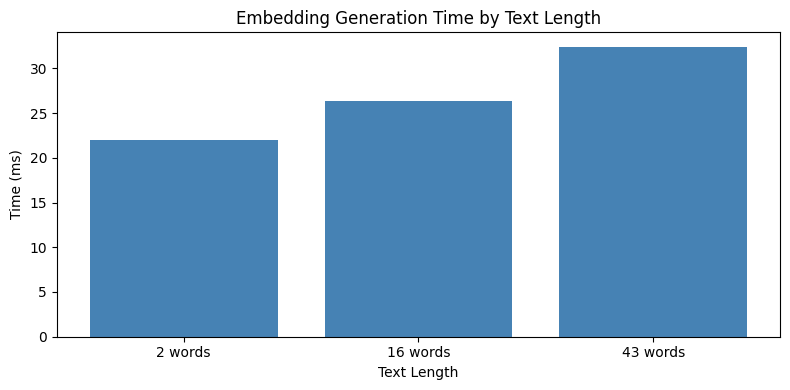

In [23]:
# Benchmark embedding generation
print("⏱️ Embedding Generation Benchmark")
print("="*50)

test_texts = [
    "Short text.",
    "This is a medium length text that contains more words and should take longer to process.",
    """This is a much longer text that simulates a typical document chunk. 
    It contains multiple sentences and covers various topics related to 
    artificial intelligence, machine learning, and natural language processing. 
    The purpose is to measure how embedding generation time scales with text length."""
]

results = []
for i, text in enumerate(test_texts):
    times = []
    for _ in range(3):  # Run 3 times for average
        start = time.time()
        _ = generate_embedding(text, config['ollama']['embedding_model'], config)
        times.append((time.time() - start) * 1000)
    
    avg_time = np.mean(times)
    results.append({
        'length': len(text),
        'words': len(text.split()),
        'avg_time_ms': avg_time
    })
    print(f"Text {i+1}: {len(text)} chars, {len(text.split())} words -> {avg_time:.2f} ms")

# Visualize
plt.figure(figsize=(8, 4))
plt.bar(range(len(results)), [r['avg_time_ms'] for r in results], color='steelblue')
plt.xticks(range(len(results)), [f"{r['words']} words" for r in results])
plt.xlabel('Text Length')
plt.ylabel('Time (ms)')
plt.title('Embedding Generation Time by Text Length')
plt.tight_layout()
plt.show()

In [24]:
# RAG query performance breakdown
print("📈 RAG Query Performance Analysis")
print("="*50)

test_queries = [
    "What is RAG?",
    "How does vector similarity search work?",
    "Explain the chunking process in detail",
    "What are the benefits of using Oracle Database for AI applications?"
]

metrics_list = []

for query in test_queries:
    try:
        result = ask_query(query=query, top_k=3, config=config)
        metrics_list.append({
            'query': query[:30] + '...',
            'embedding_ms': result['metrics'].get('embedding_time_ms', 0),
            'search_ms': result['metrics']['search_time_ms'],
            'generation_ms': result['metrics']['generation_time_ms'],
            'total_ms': result['metrics']['total_time_ms']
        })
    except Exception as e:
        print(f"Query failed: {e}")

if metrics_list:
    # Stacked bar chart
    fig, ax = plt.subplots(figsize=(10, 5))
    
    x = range(len(metrics_list))
    width = 0.6
    
    embedding = [m['embedding_ms'] for m in metrics_list]
    search = [m['search_ms'] for m in metrics_list]
    generation = [m['generation_ms'] for m in metrics_list]
    
    ax.bar(x, embedding, width, label='Embedding', color='#3498db')
    ax.bar(x, search, width, bottom=embedding, label='Search', color='#2ecc71')
    ax.bar(x, generation, width, bottom=[e+s for e,s in zip(embedding, search)], label='Generation', color='#e74c3c')
    
    ax.set_xlabel('Query')
    ax.set_ylabel('Time (ms)')
    ax.set_title('RAG Query Time Breakdown')
    ax.set_xticks(x)
    ax.set_xticklabels([m['query'] for m in metrics_list], rotation=15, ha='right')
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("\nSummary Statistics:")
    print("-"*40)
    avg_total = np.mean([m['total_ms'] for m in metrics_list])
    avg_gen = np.mean([m['generation_ms'] for m in metrics_list])
    print(f"Average total time: {avg_total:.2f} ms")
    print(f"Average generation time: {avg_gen:.2f} ms ({avg_gen/avg_total*100:.1f}% of total)")

📈 RAG Query Performance Analysis


[01/25/26 13:39:05] ERROR    Failed to generate response for model gemma3:270m                                     
                             ╭──────────────────────── Traceback (most recent call last) ─────────────────────────╮
                             │ /home/ubuntu/miniconda3/lib/python3.12/site-packages/urllib3/connectionpool.py:534 │
                             │ in _make_request                                                                   │
                             │                                                                                    │
                             │    531 │   │                                                                       │
                             │    532 │   │   # Receive the response from the server                              │
                             │    533 │   │   try:                                                                │
                             │ ❱  534 │   │   │   response = conn.getresponse()                                   │
                             │    535 │   │   except (BaseSSLError, OSError) as e:                                │
                             │    536 │   │   │   self._raise_timeout(err=e, url=url, timeout_value=read_timeout) │
                             │    537 │   │   │   raise                                                           │
                             │                                                                                    │
                             │ /home/ubuntu/miniconda3/lib/python3.12/site-packages/urllib3/connection.py:571 in  │
                             │ getresponse                                                                        │
                             │                                                                                    │
                             │    568 │   │   _shutdown = getattr(self.sock, "shutdown", None)                    │
                             │    569 │   │                                                                       │
                             │    570 │   │   # Get the response from http.client.HTTPConnection                  │
                             │ ❱  571 │   │   httplib_response = super().getresponse()                            │
                             │    572 │   │                                                                       │
                             │    573 │   │   try:                                                                │
                             │    574 │   │   │   assert_header_parsing(httplib_response.msg)                     │
                             │                                                                                    │
                             │ /home/ubuntu/miniconda3/lib/python3.12/http/client.py:1423 in getresponse          │
                             │                                                                                    │
                             │   1420 │   │                                                                       │
                             │   1421 │   │   try:                                                                │
                             │   1422 │   │   │   try:                                                            │
                             │ ❱ 1423 │   │   │   │   response.begin()                                            │
                             │   1424 │   │   │   except ConnectionError:                                         │
                             │   1425 │   │   │   │   self.close()                                                │
                             │   1426 │   │   │   │   raise                                                       │
                             │                                                                                    │
                             │ /home/ubuntu/miniconda3/l

2026-01-25 13:39:05,267 - ERROR - Failed to generate response for model gemma3:270m
Traceback (most recent call last):
  File "/home/ubuntu/miniconda3/lib/python3.12/site-packages/urllib3/connectionpool.py", line 534, in _make_request
    response = conn.getresponse()
               ^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/miniconda3/lib/python3.12/site-packages/urllib3/connection.py", line 571, in getresponse
    httplib_response = super().getresponse()
                       ^^^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/miniconda3/lib/python3.12/http/client.py", line 1423, in getresponse
    response.begin()
  File "/home/ubuntu/miniconda3/lib/python3.12/http/client.py", line 331, in begin
    version, status, reason = self._read_status()
                              ^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/miniconda3/lib/python3.12/http/client.py", line 292, in _read_status
    line = str(self.fp.readline(_MAXLINE + 1), "iso-8859-1")
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File

Query failed: Response generation failed: HTTPConnectionPool(host='localhost', port=11434): Read timed out. (read timeout=30)


[01/25/26 13:40:41] ERROR    Failed to generate response for model gemma3:270m                                     
                             ╭──────────────────────── Traceback (most recent call last) ─────────────────────────╮
                             │ /home/ubuntu/miniconda3/lib/python3.12/site-packages/urllib3/connectionpool.py:534 │
                             │ in _make_request                                                                   │
                             │                                                                                    │
                             │    531 │   │                                                                       │
                             │    532 │   │   # Receive the response from the server                              │
                             │    533 │   │   try:                                                                │
                             │ ❱  534 │   │   │   response = conn.getresponse()                                   │
                             │    535 │   │   except (BaseSSLError, OSError) as e:                                │
                             │    536 │   │   │   self._raise_timeout(err=e, url=url, timeout_value=read_timeout) │
                             │    537 │   │   │   raise                                                           │
                             │                                                                                    │
                             │ /home/ubuntu/miniconda3/lib/python3.12/site-packages/urllib3/connection.py:571 in  │
                             │ getresponse                                                                        │
                             │                                                                                    │
                             │    568 │   │   _shutdown = getattr(self.sock, "shutdown", None)                    │
                             │    569 │   │                                                                       │
                             │    570 │   │   # Get the response from http.client.HTTPConnection                  │
                             │ ❱  571 │   │   httplib_response = super().getresponse()                            │
                             │    572 │   │                                                                       │
                             │    573 │   │   try:                                                                │
                             │    574 │   │   │   assert_header_parsing(httplib_response.msg)                     │
                             │                                                                                    │
                             │ /home/ubuntu/miniconda3/lib/python3.12/http/client.py:1423 in getresponse          │
                             │                                                                                    │
                             │   1420 │   │                                                                       │
                             │   1421 │   │   try:                                                                │
                             │   1422 │   │   │   try:                                                            │
                             │ ❱ 1423 │   │   │   │   response.begin()                                            │
                             │   1424 │   │   │   except ConnectionError:                                         │
                             │   1425 │   │   │   │   self.close()                                                │
                             │   1426 │   │   │   │   raise                                                       │
                             │                                                                                    │
                             │ /home/ubuntu/miniconda3/l

...

2026-01-25 13:42:17,067 - ERROR - Failed to generate response for model gemma3:270m
Traceback (most recent call last):
  File "/home/ubuntu/miniconda3/lib/python3.12/site-packages/urllib3/connectionpool.py", line 534, in _make_request
    response = conn.getresponse()
               ^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/miniconda3/lib/python3.12/site-packages/urllib3/connection.py", line 571, in getresponse
    httplib_response = super().getresponse()
                       ^^^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/miniconda3/lib/python3.12/http/client.py", line 1423, in getresponse
    response.begin()
  File "/home/ubuntu/miniconda3/lib/python3.12/http/client.py", line 331, in begin
    version, status, reason = self._read_status()
                              ^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/miniconda3/lib/python3.12/http/client.py", line 292, in _read_status
    line = str(self.fp.readline(_MAXLINE + 1), "iso-8859-1")
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File

Query failed: Response generation failed: HTTPConnectionPool(host='localhost', port=11434): Read timed out. (read timeout=30)


[01/25/26 13:43:52] ERROR    Failed to generate response for model gemma3:270m                                     
                             ╭──────────────────────── Traceback (most recent call last) ─────────────────────────╮
                             │ /home/ubuntu/miniconda3/lib/python3.12/site-packages/urllib3/connectionpool.py:534 │
                             │ in _make_request                                                                   │
                             │                                                                                    │
                             │    531 │   │                                                                       │
                             │    532 │   │   # Receive the response from the server                              │
                             │    533 │   │   try:                                                                │
                             │ ❱  534 │   │   │   response = conn.getresponse()                                   │
                             │    535 │   │   except (BaseSSLError, OSError) as e:                                │
                             │    536 │   │   │   self._raise_timeout(err=e, url=url, timeout_value=read_timeout) │
                             │    537 │   │   │   raise                                                           │
                             │                                                                                    │
                             │ /home/ubuntu/miniconda3/lib/python3.12/site-packages/urllib3/connection.py:571 in  │
                             │ getresponse                                                                        │
                             │                                                                                    │
                             │    568 │   │   _shutdown = getattr(self.sock, "shutdown", None)                    │
                             │    569 │   │                                                                       │
                             │    570 │   │   # Get the response from http.client.HTTPConnection                  │
                             │ ❱  571 │   │   httplib_response = super().getresponse()                            │
                             │    572 │   │                                                                       │
                             │    573 │   │   try:                                                                │
                             │    574 │   │   │   assert_header_parsing(httplib_response.msg)                     │
                             │                                                                                    │
                             │ /home/ubuntu/miniconda3/lib/python3.12/http/client.py:1423 in getresponse          │
                             │                                                                                    │
                             │   1420 │   │                                                                       │
                             │   1421 │   │   try:                                                                │
                             │   1422 │   │   │   try:                                                            │
                             │ ❱ 1423 │   │   │   │   response.begin()                                            │
                             │   1424 │   │   │   except ConnectionError:                                         │
                             │   1425 │   │   │   │   self.close()                                                │
                             │   1426 │   │   │   │   raise                                                       │
                             │                                                                                    │
                             │ /home/ubuntu/miniconda3/l

2026-01-25 13:43:52,195 - ERROR - Failed to generate response for model gemma3:270m
Traceback (most recent call last):
  File "/home/ubuntu/miniconda3/lib/python3.12/site-packages/urllib3/connectionpool.py", line 534, in _make_request
    response = conn.getresponse()
               ^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/miniconda3/lib/python3.12/site-packages/urllib3/connection.py", line 571, in getresponse
    httplib_response = super().getresponse()
                       ^^^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/miniconda3/lib/python3.12/http/client.py", line 1423, in getresponse
    response.begin()
  File "/home/ubuntu/miniconda3/lib/python3.12/http/client.py", line 331, in begin
    version, status, reason = self._read_status()
                              ^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/miniconda3/lib/python3.12/http/client.py", line 292, in _read_status
    line = str(self.fp.readline(_MAXLINE + 1), "iso-8859-1")
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File

Query failed: Response generation failed: HTTPConnectionPool(host='localhost', port=11434): Read timed out. (read timeout=30)


---
## 8. Comparing Ollama vs Oracle Embeddings

Compare the two embedding generation approaches:
1. **Ollama** (default): External API calls to Ollama service
2. **Oracle** (langchain-oracledb): In-database ONNX model execution

In [25]:
# Compare Ollama vs Oracle embedding approaches
print("🔄 Embedding Approach Comparison")
print("="*50)

test_text = "Oracle Database 26ai provides enterprise-grade vector search capabilities."

# Ollama embedding
print("\n1️⃣ Ollama Embedding (nomic-embed-text):")
try:
    start = time.time()
    ollama_emb = generate_embedding(test_text, config['ollama']['embedding_model'], config)
    ollama_time = (time.time() - start) * 1000
    print(f"   Dimension: {len(ollama_emb)}")
    print(f"   Time: {ollama_time:.2f} ms")
    print(f"   Sample: [{ollama_emb[0]:.6f}, {ollama_emb[1]:.6f}, ...]")
except Exception as e:
    print(f"   Error: {e}")
    ollama_emb = None

# Oracle embedding (if available)
print("\n2️⃣ Oracle Embedding (ALL_MINILM_L12_V2):")
if HAS_ORACLE_LANGCHAIN:
    try:
        client = OracleClient(config)
        conn = client.get_connection()
        manager = OracleIntegrationManager(conn)
        
        start = time.time()
        oracle_embs = manager.generate_embeddings(
            [test_text], 
            params={"provider": "database", "model": "ALL_MINILM_L12_V2"}
        )
        oracle_time = (time.time() - start) * 1000
        
        if oracle_embs:
            oracle_emb = oracle_embs[0]
            print(f"   Dimension: {len(oracle_emb)}")
            print(f"   Time: {oracle_time:.2f} ms")
            print(f"   Sample: [{oracle_emb[0]:.6f}, {oracle_emb[1]:.6f}, ...]")
        else:
            oracle_emb = None
            print("   No embedding returned")
            
        conn.close()
        client.close()
        
    except Exception as e:
        print(f"   Error: {e}")
        oracle_emb = None
else:
    print("   Not available (langchain-oracledb not installed)")
    oracle_emb = None

# Compare if both available
if ollama_emb and oracle_emb:
    print("\n📊 Comparison:")
    print("-"*40)
    
    # Note: Different models produce different dimensions
    print(f"Ollama dimension: {len(ollama_emb)}")
    print(f"Oracle dimension: {len(oracle_emb)}")
    
    if len(ollama_emb) == len(oracle_emb):
        similarity = cosine_similarity(ollama_emb, oracle_emb)
        print(f"Cross-model similarity: {similarity:.4f}")
    else:
        print("(Different dimensions - direct comparison not possible)")
    
    print(f"\nSpeed comparison:")
    print(f"  Ollama: {ollama_time:.2f} ms")
    print(f"  Oracle: {oracle_time:.2f} ms")
    faster = "Oracle" if oracle_time < ollama_time else "Ollama"
    speedup = max(ollama_time, oracle_time) / min(ollama_time, oracle_time)
    print(f"  {faster} is {speedup:.1f}x faster")

🔄 Embedding Approach Comparison

1️⃣ Ollama Embedding (nomic-embed-text):
   Dimension: 768
   Time: 47.68 ms
   Sample: [-0.619024, 0.918454, ...]

2️⃣ Oracle Embedding (ALL_MINILM_L12_V2):
   Dimension: 384
   Time: 743.62 ms
   Sample: [-0.020795, -0.030901, ...]

📊 Comparison:
----------------------------------------
Ollama dimension: 768
Oracle dimension: 384
(Different dimensions - direct comparison not possible)

Speed comparison:
  Ollama: 47.68 ms
  Oracle: 743.62 ms
  Ollama is 15.6x faster


In [26]:
# Show how to configure Oracle embeddings in config.yaml
print("⚙️ Configuration for Oracle In-Database Embeddings")
print("="*50)

config_example = """
# config.yaml

vector_index:
  auto_select: true
  index_type: "HNSW"
  dimension: 384  # ALL_MINILM_L12_V2 produces 384-dim vectors
  
  # Enable Oracle in-database embeddings
  use_oracle_embeddings: true
  oracle_embedding_params:
    provider: "database"      # Use ONNX model in database
    model: "ALL_MINILM_L12_V2"  # Model loaded in Oracle DB

# Alternative providers:
#   provider: "ocigenai"  # OCI GenAI with Cohere
#   provider: "huggingface"  # HuggingFace models
"""

print(config_example)
print("\nBenefits of Oracle in-database embeddings:")
print("• No external API calls - data never leaves the database")
print("• Lower latency for high-volume workloads")
print("• Enterprise security and compliance")
print("• Simplified architecture - fewer moving parts")

⚙️ Configuration for Oracle In-Database Embeddings

# config.yaml

vector_index:
  auto_select: true
  index_type: "HNSW"
  dimension: 384  # ALL_MINILM_L12_V2 produces 384-dim vectors

  # Enable Oracle in-database embeddings
  use_oracle_embeddings: true
  oracle_embedding_params:
    provider: "database"      # Use ONNX model in database
    model: "ALL_MINILM_L12_V2"  # Model loaded in Oracle DB

# Alternative providers:
#   provider: "ocigenai"  # OCI GenAI with Cohere
#   provider: "huggingface"  # HuggingFace models


Benefits of Oracle in-database embeddings:
• No external API calls - data never leaves the database
• Lower latency for high-volume workloads
• Enterprise security and compliance
• Simplified architecture - fewer moving parts


---
## Cleanup

In [27]:
# Cleanup demo files
import shutil

cleanup = input("Delete demo files? (y/n): ").lower().strip() == 'y'

if cleanup:
    try:
        shutil.rmtree(sample_dir)
        print(f"✅ Deleted {sample_dir}")
    except Exception as e:
        print(f"⚠️ Could not delete: {e}")
else:
    print(f"Demo files preserved in: {sample_dir}")

Demo files preserved in: demo_data


---
## Summary

This notebook demonstrated the key capabilities of **ragcli**:

### Core RAG Pipeline
- Document preprocessing and text extraction
- Token-based chunking with overlap
- Embedding generation (Ollama or Oracle)
- Vector storage with HNSW indexing
- Similarity search and retrieval
- LLM-powered response generation

### langchain-oracledb Features
- **OracleDocLoader**: Database-integrated document loading
- **OracleTextSplitter**: Server-side chunking with normalization
- **OracleEmbeddings**: In-database ONNX model execution
- **OracleSummary**: Database-powered summarization

### Key Configuration Options
- `use_oracle_embeddings: true` - Enable in-database embeddings
- `use_oracle_splitter: true` - Enable server-side chunking
- `use_oracle_loader: true` - Enable Oracle document loader

### Next Steps
1. Explore the CLI: `python ragcli.py`
2. Try the API: `python ragcli.py api --port 8000`
3. Launch the frontend: `cd frontend && npm run dev`
4. Run Oracle tests: `python ragcli.py oracle-test all`